In [1]:
import pandas as pd 

df=pd.read_csv("../data/processed/cleaned_data.csv")
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0,-0.350151,1.641931
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,-0.254117,1.641952
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,-0.081839,1.641974
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0,-0.313249,1.641974


<Figure size 1400x800 with 0 Axes>

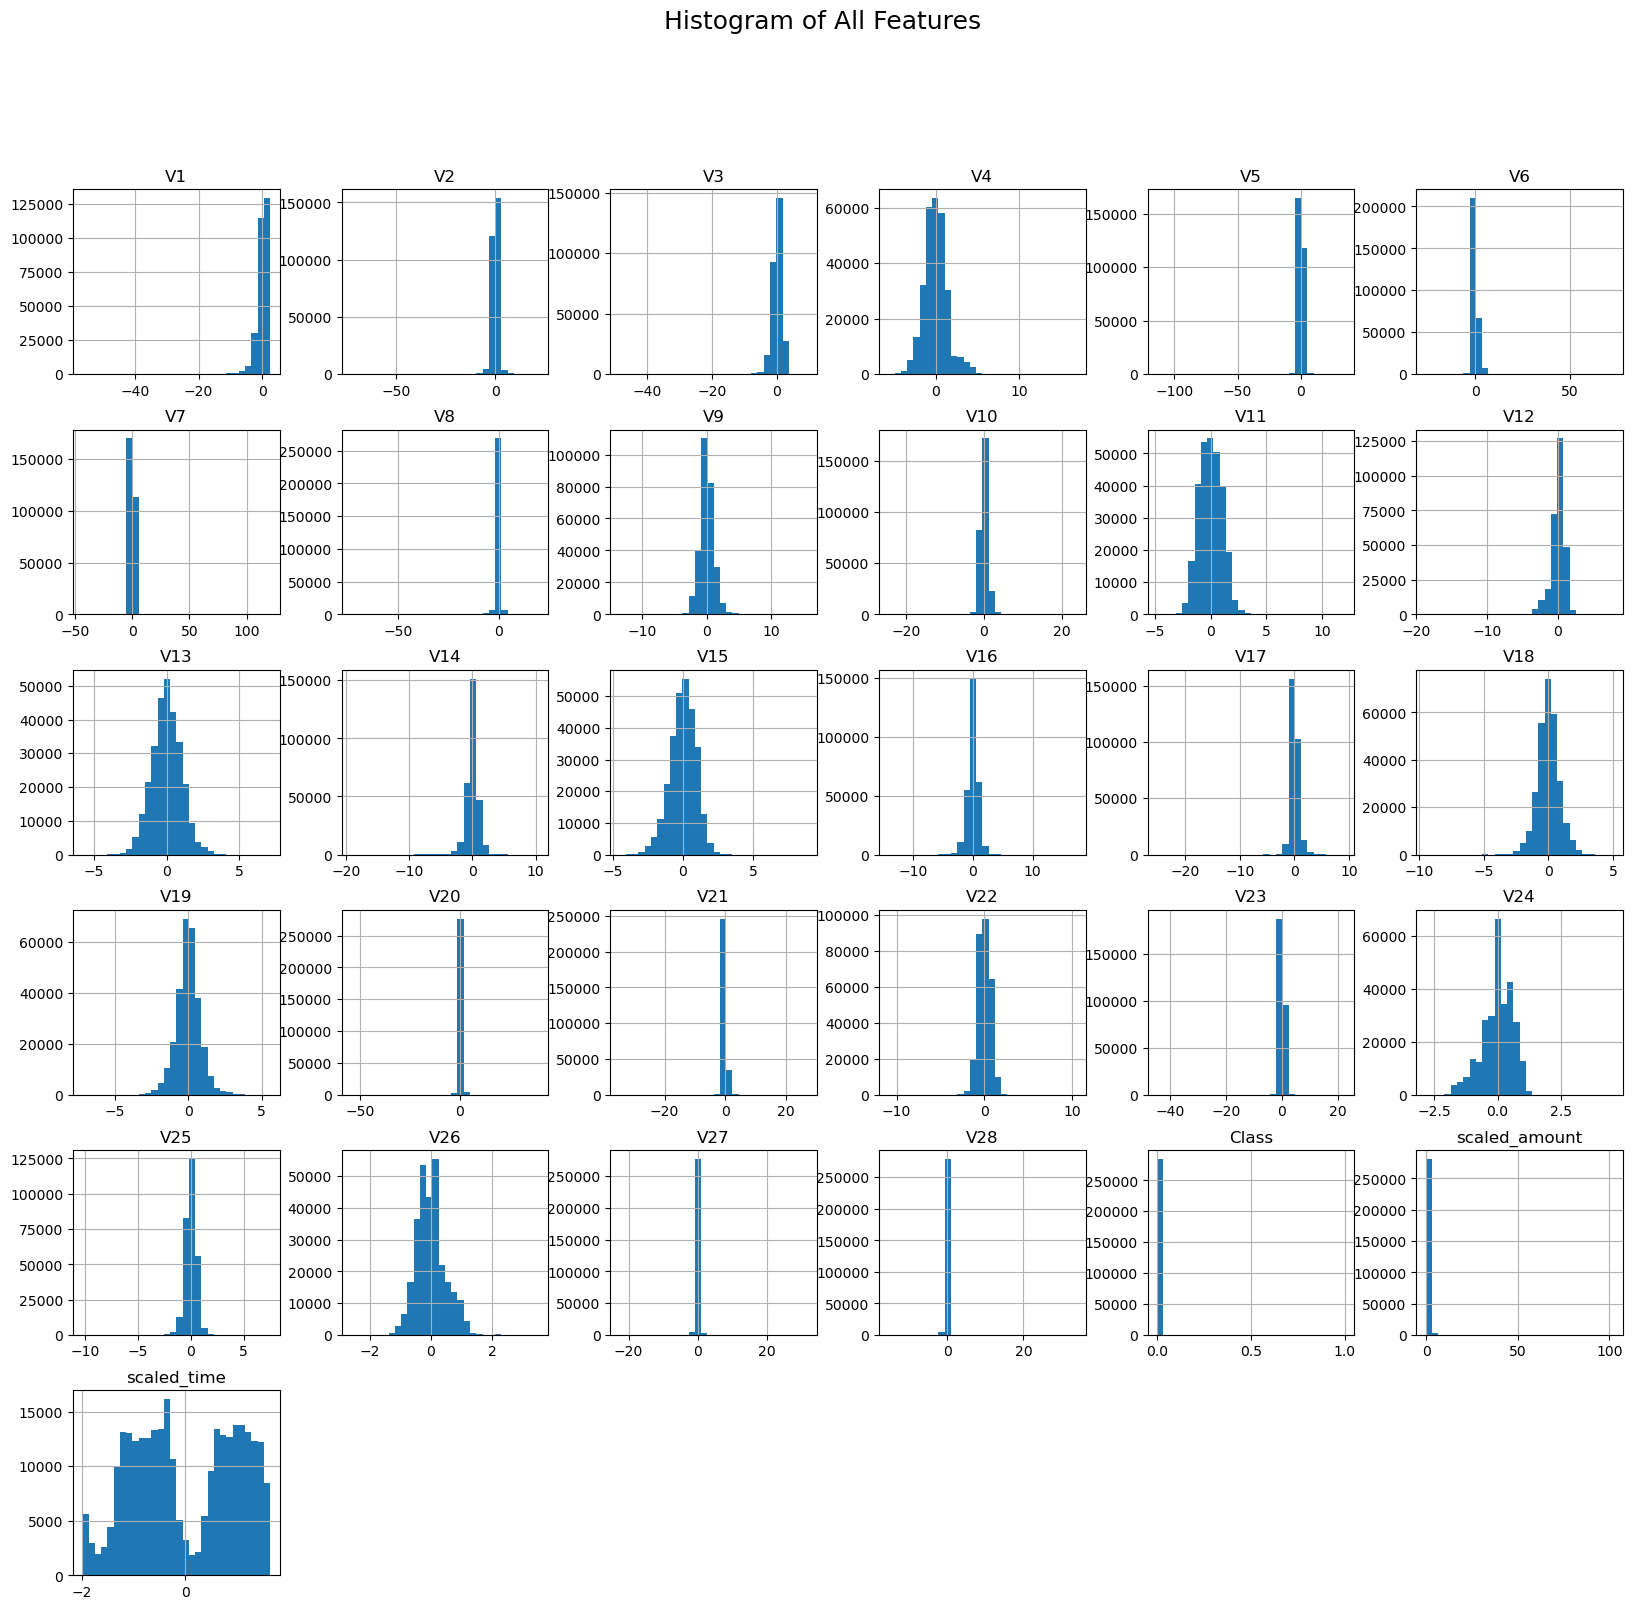

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

df.hist(bins=30, figsize=(20, 18))
plt.suptitle("Histogram of All Features", fontsize=18)
plt.show()


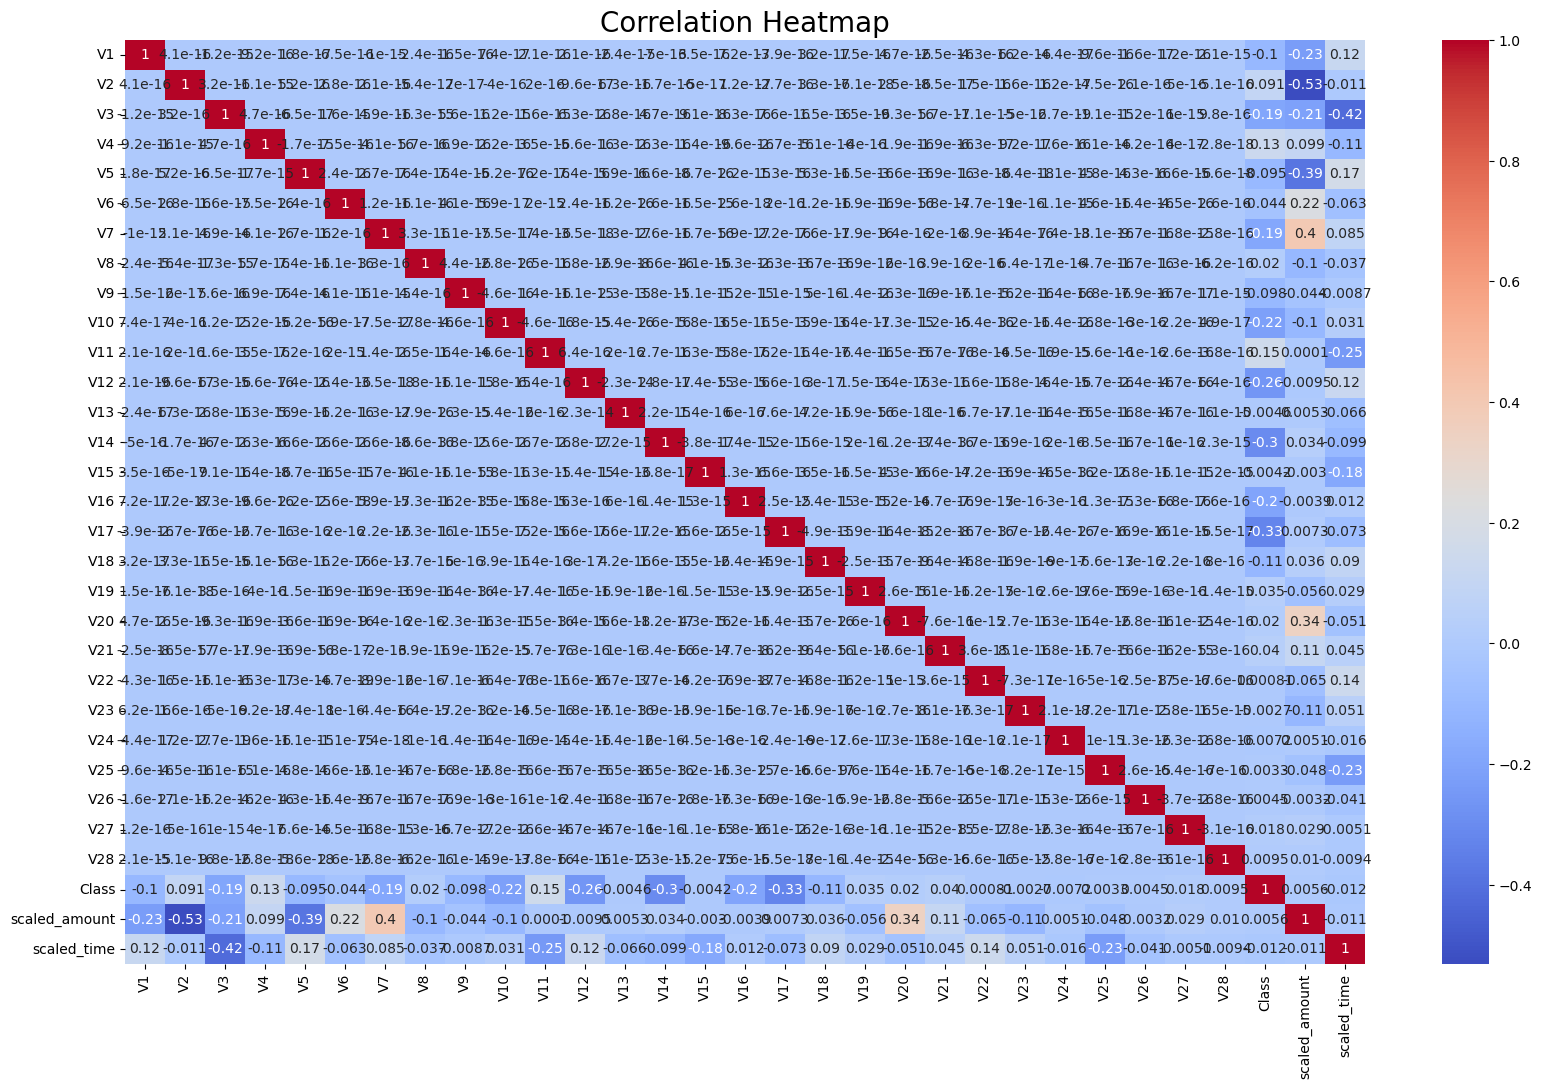

In [4]:
plt.figure(figsize=(20,12))
corr = df.corr()

sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title('Correlation Heatmap', fontsize=20)
plt.show()

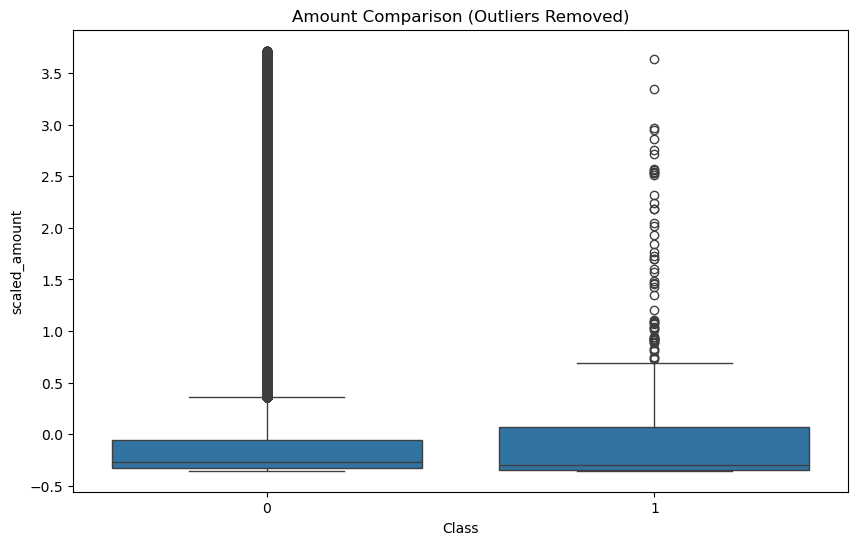

In [5]:
q_low = df['scaled_amount'].quantile(0.01)
q_high = df['scaled_amount'].quantile(0.99)

df_trim = df[(df['scaled_amount'] > q_low) & (df['scaled_amount'] < q_high)]

plt.figure(figsize=(10,6))
sns.boxplot(x='Class', y='scaled_amount', data=df_trim)
plt.title("Amount Comparison (Outliers Removed)")
plt.show()

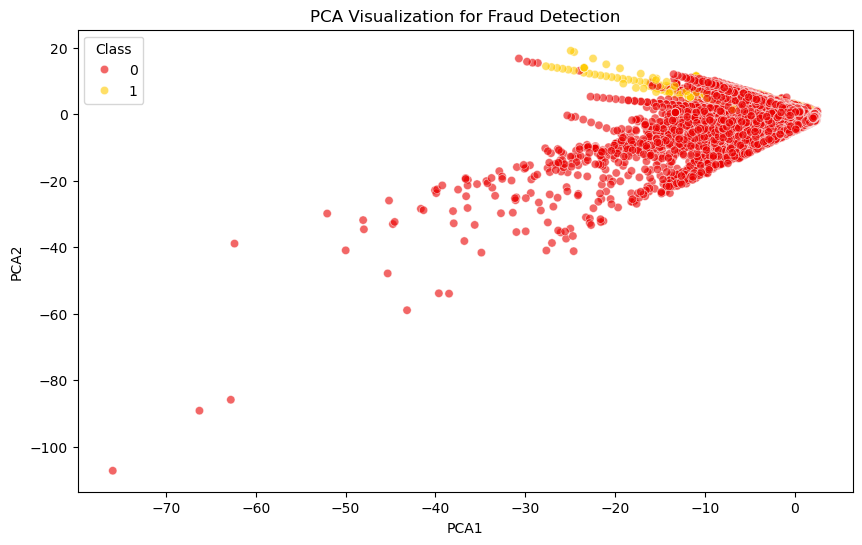

In [6]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df.drop("Class", axis=1))

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue=df["Class"], palette="hot", alpha=0.6)
plt.title("PCA Visualization for Fraud Detection")
plt.show()

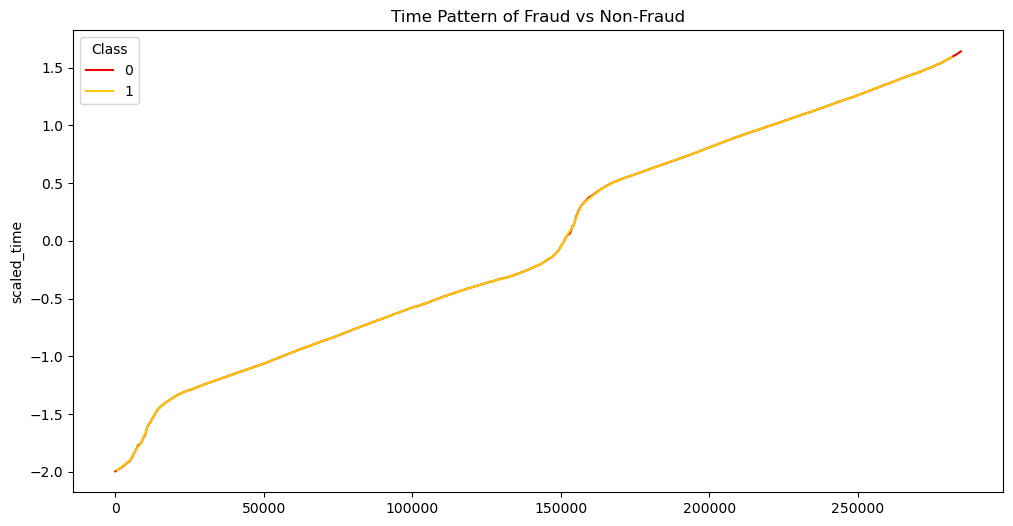

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=range(len(df)), y='scaled_time', hue='Class', palette='hot')
plt.title("Time Pattern of Fraud vs Non-Fraud")
plt.show()

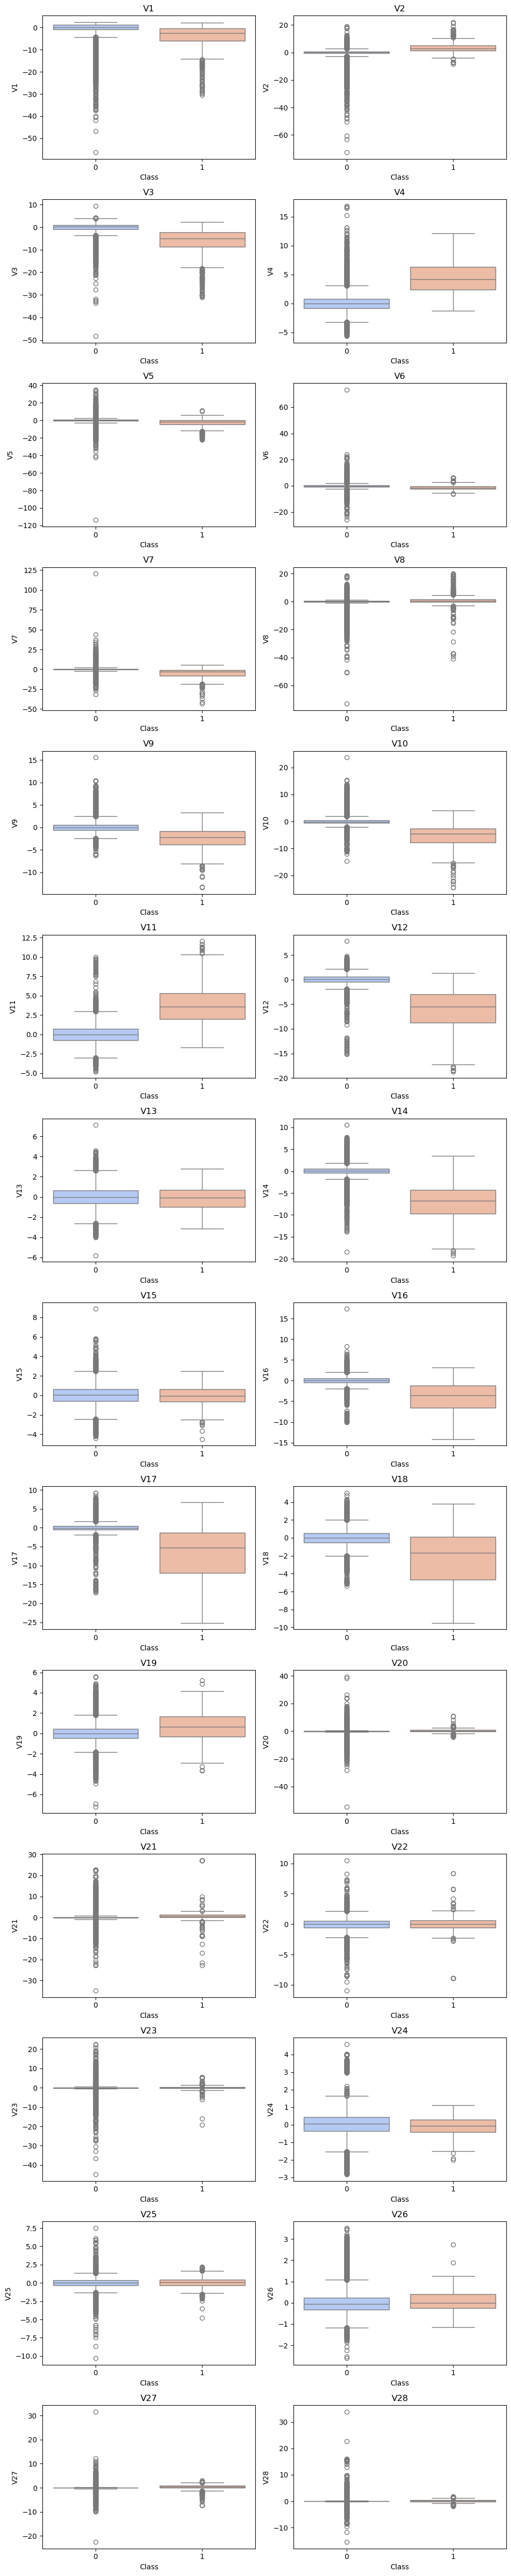

In [8]:
plt.figure(figsize=(10, 50))

for i in range(1, 29):
    plt.subplot(14, 2, i)
    sns.boxplot(x="Class", y=f"V{i}", data=df, hue="Class", palette="coolwarm", legend=False)
    plt.title(f"V{i}")

plt.tight_layout()
plt.show()


In [9]:
eda_report = {
    "Total Transactions": len(df),
    "Fraud Transactions": len(df[df.Class == 1]),
    "Non-Fraud Transactions": len(df[df.Class == 0]),
    "Fraud Percentage": round(df['Class'].mean()*100, 4),
    "Columns": list(df.columns),
    "Missing Values": df.isnull().sum().to_dict() }
eda_report

{'Total Transactions': 284807,
 'Fraud Transactions': 492,
 'Non-Fraud Transactions': 284315,
 'Fraud Percentage': np.float64(0.1727),
 'Columns': ['V1',
  'V2',
  'V3',
  'V4',
  'V5',
  'V6',
  'V7',
  'V8',
  'V9',
  'V10',
  'V11',
  'V12',
  'V13',
  'V14',
  'V15',
  'V16',
  'V17',
  'V18',
  'V19',
  'V20',
  'V21',
  'V22',
  'V23',
  'V24',
  'V25',
  'V26',
  'V27',
  'V28',
  'Class',
  'scaled_amount',
  'scaled_time',
  'PCA1',
  'PCA2'],
 'Missing Values': {'V1': 0,
  'V2': 0,
  'V3': 0,
  'V4': 0,
  'V5': 0,
  'V6': 0,
  'V7': 0,
  'V8': 0,
  'V9': 0,
  'V10': 0,
  'V11': 0,
  'V12': 0,
  'V13': 0,
  'V14': 0,
  'V15': 0,
  'V16': 0,
  'V17': 0,
  'V18': 0,
  'V19': 0,
  'V20': 0,
  'V21': 0,
  'V22': 0,
  'V23': 0,
  'V24': 0,
  'V25': 0,
  'V26': 0,
  'V27': 0,
  'V28': 0,
  'Class': 0,
  'scaled_amount': 0,
  'scaled_time': 0,
  'PCA1': 0,
  'PCA2': 0}}

In [10]:
df.to_csv("../data/processed/creditcard_eda_processed.csv", index=False)